In [2]:
import pandas as pd

import snman_abm
import snman
import random
import os
import matplotlib.pyplot as plt
import copy
import importlib

PROJECT = '_main'
data_directory = os.path.join('C:',os.sep,'Users','shiry', 'snman_sgProject')
export_path = os.path.join(data_directory, 'outputs', PROJECT)
inputs_path = os.path.join(data_directory, 'inputs', PROJECT)

G = snman.io.load_street_graph(
    edges_path=os.path.join(export_path, 'G_edges.gpkg'),
    nodes_path=os.path.join(export_path, 'G_nodes.gpkg'),
    crs=3414
)

nodes = list(G.nodes())

## Run the Model for Before and After Network Reallocation

In [3]:
template_before = snman_abm.Network(scenario="before", n=0, od_pairs=[])
template_after = snman_abm.Network(scenario="after", n=0, od_pairs=[])

base_car_before = copy.deepcopy(template_before.car_graph)
base_car_after = copy.deepcopy(template_after.car_graph)

base_bike_before = copy.deepcopy(template_before.bike_graph)
base_bike_after = copy.deepcopy(template_after.bike_graph)

In [4]:
results = []
trip_lengths = []

n_runs = 100
n_agents = 1000

for run in range(n_runs):
    od_pairs = []
    while len(od_pairs) < n_agents:
        origin = random.choice(nodes)
        destination = random.choice(nodes)

        if origin == destination:
            continue

        od_pairs.append((origin, destination))

    model_before = snman_abm.Network(
        scenario="before",
        n=n_agents,
        od_pairs=od_pairs,
        car_graph=copy.deepcopy(base_car_before),
        bike_graph=copy.deepcopy(base_bike_before),
    )

    model_after = snman_abm.Network(
        scenario="after",
        n=n_agents,
        od_pairs=od_pairs,
        car_graph=copy.deepcopy(base_car_after),
        bike_graph=copy.deepcopy(base_bike_after),
    )

    max_steps = int((model_before.end_time - model_before.start_time) / model_before.step_time)

    steps = 0
    while any(not agent.has_traveled for agent in model_before.schedule.agents) and steps < max_steps:
        model_before.step()
        steps += 1

    max_steps = int((model_after.end_time - model_after.start_time) / model_after.step_time)

    steps = 0
    while any(not agent.has_traveled for agent in model_after.schedule.agents) and steps < max_steps:
        model_after.step()
        steps += 1

    df_before = model_before.get_journeys()
    df_after = model_after.get_journeys()

    trip_lengths.extend((df_before["distance_m"] / 1000).tolist())

    before_counts = df_before["mode"].value_counts(normalize=True)
    after_counts = df_after["mode"].value_counts(normalize=True)

    bike_before = before_counts.get("bike", 0)
    bike_after = after_counts.get("bike", 0)

    results.append({
        "run": run + 1,
        "bike_before": bike_before,
        "bike_after": bike_after,
        "change": bike_after - bike_before,
    })

    print(f"Run {run+1}/{n_runs} done. Bike before: {bike_before:.3f}, after: {bike_after:.3f}")

Run 1/100 done. Bike before: 0.174, after: 0.205
Run 2/100 done. Bike before: 0.137, after: 0.200
Run 3/100 done. Bike before: 0.146, after: 0.212
Run 4/100 done. Bike before: 0.147, after: 0.201
Run 5/100 done. Bike before: 0.144, after: 0.224
Run 6/100 done. Bike before: 0.145, after: 0.203
Run 7/100 done. Bike before: 0.178, after: 0.233
Run 8/100 done. Bike before: 0.144, after: 0.205
Run 9/100 done. Bike before: 0.143, after: 0.197
Run 10/100 done. Bike before: 0.160, after: 0.210
Run 11/100 done. Bike before: 0.137, after: 0.199
Run 12/100 done. Bike before: 0.147, after: 0.209
Run 13/100 done. Bike before: 0.155, after: 0.214
Run 14/100 done. Bike before: 0.145, after: 0.208
Run 15/100 done. Bike before: 0.157, after: 0.185
Run 16/100 done. Bike before: 0.154, after: 0.209
Run 17/100 done. Bike before: 0.148, after: 0.200
Run 18/100 done. Bike before: 0.142, after: 0.201
Run 19/100 done. Bike before: 0.131, after: 0.184
Run 20/100 done. Bike before: 0.156, after: 0.233
Run 21/10

## Trip Details

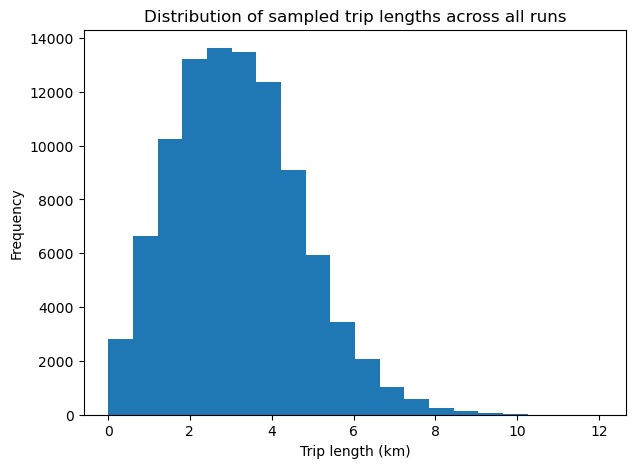

In [5]:
plt.figure(figsize=(7, 5))
plt.hist(trip_lengths, bins=20)
plt.xlabel("Trip length (km)")
plt.ylabel("Frequency")
plt.title("Distribution of sampled trip lengths across all runs")
plt.show()

## Mode Share Analysis

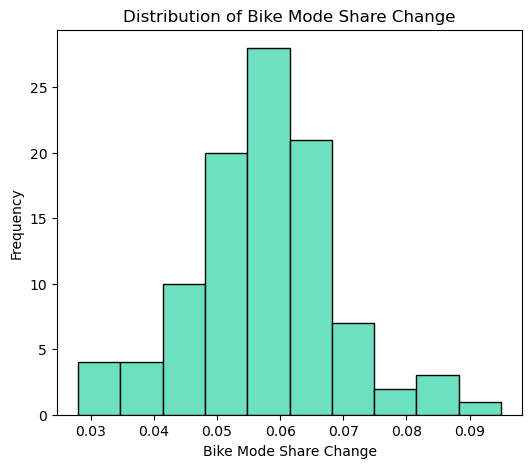

In [6]:
# plot histogram of mode share change across all the runs
results_df = pd.DataFrame(results)
plt.figure(figsize=(6, 5))
plt.hist(results_df["change"], bins=10, edgecolor="black", color="#6BE1C0")

plt.xlabel("Bike Mode Share Change")
plt.ylabel("Frequency")
plt.title("Distribution of Bike Mode Share Change")
plt.show()

In [7]:
mean_before = results_df["bike_before"].mean()
mean_after = results_df["bike_after"].mean()
std_before = results_df["bike_before"].std()
std_after = results_df["bike_after"].std()

print("Mean change:", results_df["change"].mean())
print("Std dev:", results_df["change"].std())
print("Min change:", results_df["change"].min())
print("Max change:", results_df["change"].max())

Mean change: 0.057633447516312115
Std dev: 0.011621649936296196
Min change: 0.02801358968152426
Max change: 0.0949537079573596


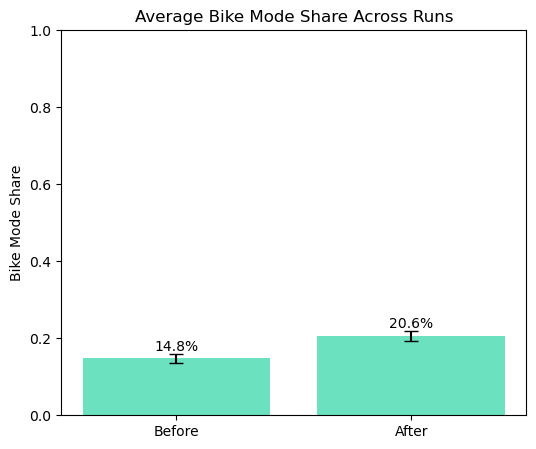

In [8]:
# plot avg bike mode share before and after, across runs
labels = ["Before", "After"]
means = [mean_before, mean_after]
errors = [std_before, std_after]

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, means, yerr=errors, capsize=5, color="#6BE1C0")

plt.ylabel("Bike Mode Share")
plt.title("Average Bike Mode Share Across Runs")
plt.ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height*100:.1f}%",
        ha="center"
    )

plt.show()

mode               bike       car
distance_band                    
0-1            0.860759  0.139241
1-2            0.474684  0.525316
2-3            0.045455  0.954545
3-5            0.022472  0.977528
5+             0.034783  0.965217


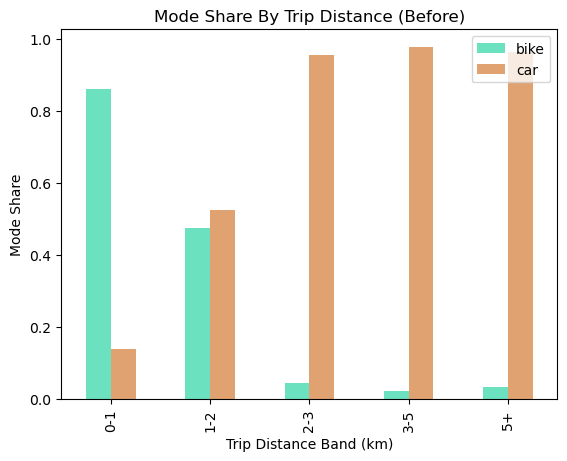

In [9]:
bins = [0, 1, 2, 3, 5, 10]  # km
labels = ["0-1", "1-2", "2-3", "3-5", "5+"]

df_before["distance_km"] = df_before["distance_m"] / 1000
df_before["distance_band"] = pd.cut(df_before["distance_km"], bins=bins, labels=labels)

mode_by_dist = pd.crosstab(df_before["distance_band"], df_before["mode"], normalize="index")
print(mode_by_dist)

mode_by_dist.plot(kind="bar", color=["#6BE1C0", "#E1A272"])
plt.xlabel("Trip Distance Band (km)")
plt.ylabel("Mode Share")
plt.title("Mode Share By Trip Distance (Before)")
plt.legend(loc="upper right")
plt.show()

mode               bike       car
distance_band                    
0-1            0.901235  0.098765
1-2            0.723404  0.276596
2-3            0.090909  0.909091
3-5            0.015748  0.984252
5+             0.004926  0.995074


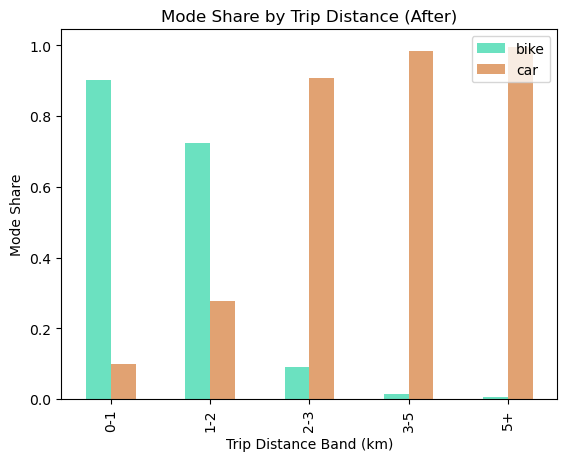

In [10]:
bins = [0, 1, 2, 3, 5, 10]  # km
labels = ["0-1", "1-2", "2-3", "3-5", "5+"]

df_after["distance_km"] = df_after["distance_m"] / 1000
df_after["distance_band"] = pd.cut(df_after["distance_km"], bins=bins, labels=labels)

mode_by_dist = pd.crosstab(df_after["distance_band"], df_after["mode"], normalize="index")
print(mode_by_dist)

mode_by_dist.plot(kind="bar", color=["#6BE1C0", "#E1A272"])
plt.xlabel("Trip Distance Band (km)")
plt.ylabel("Mode Share")
plt.title("Mode Share by Trip Distance (After)")
plt.legend(loc="upper right")
plt.show()

## Congestion and Traffic Flow

In [11]:
network_stats_before = pd.DataFrame(model_before.network_stats)
network_stats_after = pd.DataFrame(model_after.network_stats)

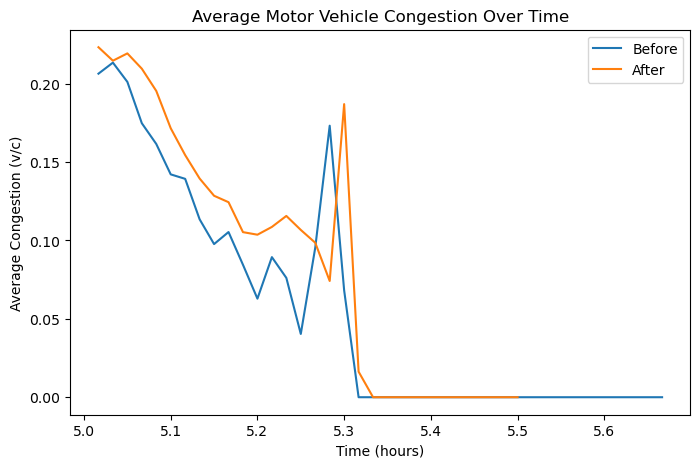

In [12]:
plt.figure(figsize=(8,5))

plt.plot(network_stats_before["time"], network_stats_before["average_congestion"], label="Before")
plt.plot(network_stats_after["time"], network_stats_after["average_congestion"], label="After")

plt.xlabel("Time (hours)")
plt.ylabel("Average Congestion (v/c)")
plt.title("Average Motor Vehicle Congestion Over Time")
plt.legend()

plt.show()

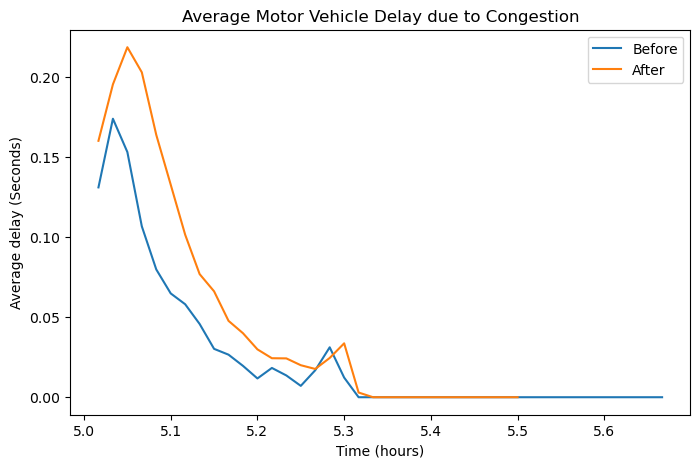

In [13]:
plt.figure(figsize=(8,5))

plt.plot(network_stats_before["time"], network_stats_before["average_delay"] * 3600, label="Before")
plt.plot(network_stats_after["time"], network_stats_after["average_delay"] * 3600, label="After")

plt.xlabel("Time (hours)")
plt.ylabel("Average delay (Seconds)")
plt.title("Average Motor Vehicle Delay due to Congestion")
plt.legend()

plt.show()

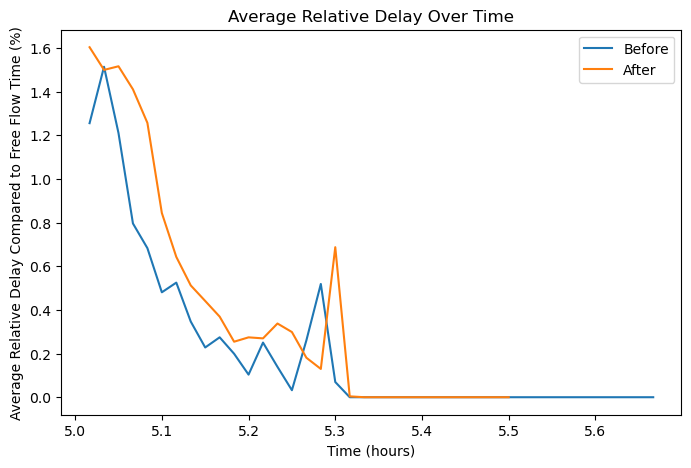

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(network_stats_before["time"], network_stats_before["average_relative_delay"] * 100, label="Before")
plt.plot(network_stats_after["time"], network_stats_after["average_relative_delay"] * 100, label="After")
plt.xlabel("Time (hours)")
plt.ylabel("Average Relative Delay Compared to Free Flow Time (%)")
plt.title("Average Relative Delay Over Time")
plt.legend()
plt.show()

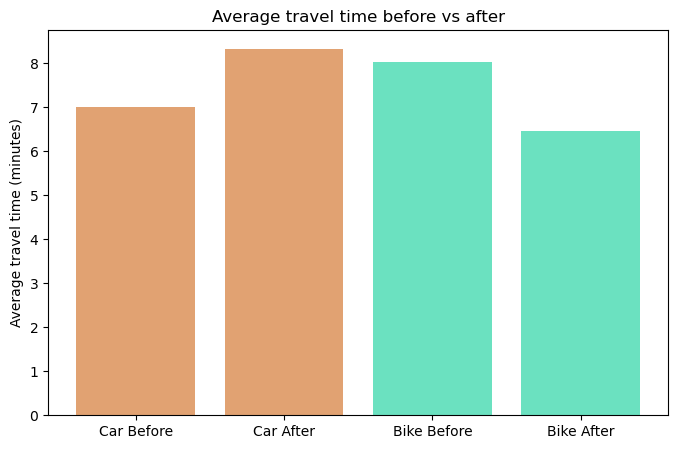

In [15]:
car_before = df_before[df_before["mode"] == "car"]["travel_time"].mean() * 60
car_after = df_after[df_after["mode"] == "car"]["travel_time"].mean() * 60

bike_before = df_before[df_before["mode"] == "bike"]["travel_time"].mean() * 60
bike_after = df_after[df_after["mode"] == "bike"]["travel_time"].mean() * 60

labels = ["Car Before", "Car After", "Bike Before", "Bike After"]
values = [car_before, car_after, bike_before, bike_after]

plt.figure(figsize=(8,5))
plt.bar(labels, values,color=["#E1A272", "#E1A272", "#6BE1C0", "#6BE1C0"])

plt.ylabel("Average travel time (minutes)")
plt.title("Average travel time before vs after")

plt.show()